Global Solution 2026

Alunos: Anna Cecília Guimarães Maiques Lima de Carvalho, Fernando Bonfim Hoefle, Lucas Parkin Devito

RM: 570955, 569920, 573251

Turma: 1CCA

O sistema simula o monitoramento de uma missão espacial utilizando os dados operacionais que podem ser informados pelo usuário de maneira manual ou aleatória, e organizadas e apresentadas de forma estruturada por meio de tabelas e gráficos, permitindo uma visualização clara do estado atual da nave. A IA recebe as informações coletadas, que são relacionadas a temperatura da nave, o nível de energia disponível, o status da comunicação e a condição do sistema de geração de energia solar.

Com base nos dados fornecidos, o modelo realiza uma análise contextual da situação da missão, identificando possíveis riscos, avaliando os alertas gerados pelo sistema e sugerindo ações corretivas para a equipe de controle. Dessa forma, permitindo uma análise mais detalhada e inteligente dos dados monitorados.


In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import random

!pip install openai
from google.colab import userdata
from openai import OpenAI
api_key = userdata.get("OPENAI_API_KEY")
client = OpenAI(api_key=api_key)

In [79]:
#Inserir os dados yayyyy
modo = input(
    "Escolha o modo (manual ou aleatório): "
).strip().lower()

if modo == "aleatório":

    temperatura = random.randint(15, 40)

    energia = random.randint(0, 100)

    comunicacao = random.choice([
        "Operando",
        "Falha"
    ])

    energia_solar = random.choice([
        "Ativo",
        "Inativo"
    ])

    print(f"Temperatura: {temperatura} °C")
    print(f"Energia: {energia}%")
    print(f"Comunicação: {comunicacao}")
    print(f"Energia Solar: {energia_solar}")

else:

    temperatura = float(input("Digite a temperatura: "))

    energia = float(input("Digite o nível de energia (%): "))

    comunicacao = input("Digite o status da comunicação (Operando/Falha): ")

    energia_solar = input("Energia solar (Ativo/Inativo): ")

Escolha o modo (manual ou aleatório): aleatório
Temperatura: 21 °C
Energia: 81%
Comunicação: Falha
Energia Solar: Inativo


In [80]:
dados = {  #Organizando e estruturando os dados -_-
    "Indicador": [
        "Temperatura",
        "Energia",
        "Comunicação",
        "Energia Solar"
    ],
           "Valor": [
               temperatura,
               energia,
               comunicacao,
               energia_solar
           ]
}

df = pd.DataFrame(dados) #forma o grafico
display(df)

,Indicador,Valor
0,Temperatura,21
1,Energia,81
2,Comunicação,Falha
3,Energia Solar,Inativo


In [81]:
alertas = [] #sistema de alertas

#Temperatura
if temperatura > 30:
  alertas.append("Temperatura CRÍTICA") # append adiciona na lista ;)
  print("Temperatura CRÍTICA")
elif temperatura > 24:
  alertas.append("Temperatura Atenção")
  print("Atenção na Temperatura")
elif temperatura < 19:
  alertas.append("Baixa Temperatura")
  print("Baixa temperatura")
else:
  alertas.append("Temperatura Normal")
  print("Temperatura Normal")


Temperatura Normal


In [82]:
#Energia

if energia < 25:
  alertas.append("Energia baixa")
  print(f"Energia baixa  {energia}%")
elif energia < 70:
  alertas.append("Energia moderada")
  print(f"Energia moderada  {energia}%")
elif energia > 71:
  alertas.append("Energia Completa")
  print(f"Energia Completa  {energia}%")
else:
  alertas.append("Energia zerada(0)")
  print("Energia zerada(0)")

Energia Completa  81%


In [83]:
#comunicacao

if comunicacao.lower() == "falha":
  alertas.append("Falha de comunicação")
  print("Falha na comunicação")
else:
  alertas.append("Comunicação estavel")
  print("Comunicação estável")

Falha na comunicação


In [84]:
#Energia Solar

if energia_solar.lower() == "ativo":
  alertas.append("Gerador de energia solar ativo")
  print("Gerador de energia solar ativo")
else:
  alertas.append("Gerador de energia solar inativo")
  print("Gerador de energia solar inativo")

Gerador de energia solar inativo


In [85]:
for alerta in alertas:
  print(alerta)

Temperatura Normal
Energia Completa
Falha de comunicação
Gerador de energia solar inativo


In [86]:

acoes = [] #cria lista de ações que o sistema pode tomar ¨-¨

if temperatura > 30:
  acoes.append("Ativar sistema de resfriamento")
  print("Ative o sistema de resfriamento")
elif temperatura < 20:
  acoes.append("Desligar sistema de resfriamento")
  print("Desligue o sistema de resfriamento")

if energia > 22 and energia <= 40:

  if energia_solar.lower() == "ativo": #Se a energia estiver baixa, mas não muito, dá pra carregar
    acoes.append("Redirecionar energia dos painéis solares para recarga")
    print("Redirecionar energia dos painéis solares para recarga")

if energia <= 22: #se chegou aqui, ferrou, liga outra bateria (corrected syntax)
  acoes.append("Ativar bateria reserva")
  print("Ative a bateria reserva")

if comunicacao.lower() == "falha":
  acoes.append("Reiniciar sistema de comunicação")
  print("Reinicie o sistema de comunicação")


else:
  acoes.append("Tudo em ordem")


Reinicie o sistema de comunicação


In [87]:
#mostrando as ações bonitinho ;)
print("Ações Recomendadas:")
for action in acoes:
    print(f"- {action}")

Ações Recomendadas:
- Reiniciar sistema de comunicação


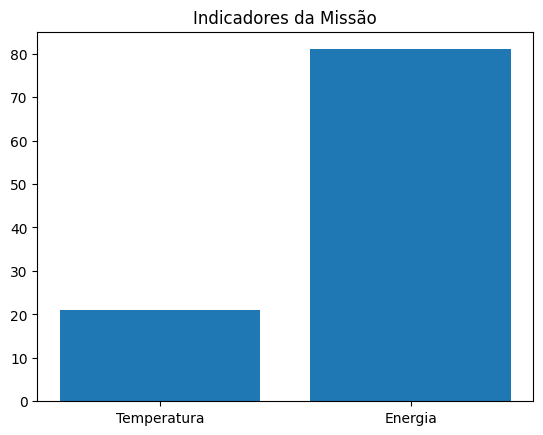

In [88]:
#Grafico da temperatura e energia ´-´
plt.bar(
    ["Temperatura","Energia"],
    [temperatura, energia]
)

plt.title("Indicadores da Missão")
plt.show()

In [89]:
saude = 100 #o estado da nave, em perfeita condição teria 100 ;)

if temperatura > 30:
  saude -= 15 #perde "pontos" :(
elif temperatura > 24:
  saude -= 15
elif temperatura < 19:
  saude -= 10

if energia < 25:
  saude -= 30

if comunicacao.lower() == "falha":
  saude -= 40

if energia_solar.lower() == "inativo":
  saude -= 20

if saude < 0:
  saude = 0

print(f"Saúde da missão: {saude}%")

Saúde da missão: 40%


In [90]:
#Tabela mostrando o estado geral da nave
geral = pd.DataFrame({
    "Indicador": [
        "Saúde da Missão",
        "Status"
    ],
    "Valor": [
        f"{saude}%",
        status
    ]
})

display(geral)

,Indicador,Valor
0,Saúde da Missão,40%
1,Status,CRÍTICO


In [91]:
if saude >= 80:
  status = "NORMAL"
elif saude >= 50:
  status = "ATENÇÃO"
else:
  status = "CRÍTICO"

print(f"Status da missão {status}")


Status da missão CRÍTICO


In [92]:
system_prompt = """
Você é um especialista em monitoramento de missões espaciais.

Analise os dados da missão.

Verifique:

- temperatura
- energia
- comunicação
- energia solar
- saúde da missão

Explique:

1. Estado geral da missão
2. Principais riscos
3. Recomendações

Responda em português.
"""
dados_missao = f"""
Temperatura: {temperatura} °C

Energia: {energia} %

Comunicação: {comunicacao}

Energia Solar: {energia_solar}

Saúde da Missão: {saude} %

Status: {status}

Alertas:
{",".join(alertas)}

Ações:
{",".join(acoes)}
"""

resposta = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[
        {
            "role": "system",
            "content": system_prompt
        },
        {
            "role": "user",
            "content": dados_missao
        }
    ]
)

analise_ia = resposta.choices[0].message.content


In [93]:
print("\n ANÁLISE DA IA \n")

print(analise_ia)


 ANÁLISE DA IA 

### Análise da Missão

1. **Estado geral da missão:**
   A missão apresenta um estado crítico, com a temperatura operando dentro dos limites normais (21 °C) e a energia disponível em 81%, o que é razoável. Contudo, a falha na comunicação e a inatividade do gerador de energia solar são preocupantes. Além disso, a saúde da missão foi classificada em apenas 40%, indicando que a missão está enfrentando sérios desafios que podem comprometer sua continuidade e eficácia.

2. **Principais riscos:**
   - **Falha de Comunicação:** A incapacidade de se comunicar pode resultar na falta de controle e monitoramento da missão, inviabilizando a capacidade de receber dados ou enviar comandos.
   - **Inatividade do Gerador de Energia Solar:** A falta de energia solar pode levar ao esgotamento das fontes de energia, o que é crítico para a manutenção dos sistemas vitais da missão.
   - **Baixa Saúde da Missão:** Com apenas 40% de saúde, o risco de falhas adicionais em outros sistemas aum

In [94]:
print("\n Resumo Completo da Missão \n")

resumo_data = {
    "Indicador": [
        "Temperatura (C)",
        "Energia (%)",
        "Comunicação",
        "Energia Solar",
        "Alertas",
        "Ações Recomendadas",
        "Saúde da Missão (%)",
        "Status Geral",
        "Análise da IA"
    ],
    "Valor": [
        temperatura,
        energia,
        comunicacao,
        energia_solar,
        "; ".join(alertas),
        "; ".join(acoes),
        saude,
        status,
        analise_ia
    ]
}

resumo_df = pd.DataFrame(resumo_data)

for index, row in resumo_df.iterrows():
    print(f"{row['Indicador']}: {row['Valor']}")


 Resumo Completo da Missão 

Temperatura (C): 21
Energia (%): 81
Comunicação: Falha
Energia Solar: Inativo
Alertas: Temperatura Normal; Energia Completa; Falha de comunicação; Gerador de energia solar inativo
Ações Recomendadas: Reiniciar sistema de comunicação
Saúde da Missão (%): 40
Status Geral: CRÍTICO
Análise da IA: ### Análise da Missão

1. **Estado geral da missão:**
   A missão apresenta um estado crítico, com a temperatura operando dentro dos limites normais (21 °C) e a energia disponível em 81%, o que é razoável. Contudo, a falha na comunicação e a inatividade do gerador de energia solar são preocupantes. Além disso, a saúde da missão foi classificada em apenas 40%, indicando que a missão está enfrentando sérios desafios que podem comprometer sua continuidade e eficácia.

2. **Principais riscos:**
   - **Falha de Comunicação:** A incapacidade de se comunicar pode resultar na falta de controle e monitoramento da missão, inviabilizando a capacidade de receber dados ou enviar c